# Feature Engineering — F1 Pit Stop Prediction
**Objectif :** Prédire `PitNextLap` — est-ce qu'un pilote va rentrer aux stands le tour suivant ?

**Dataset original :** 439 140 lignes · 16 colonnes · Saisons 2022–2025  
**Dataset utilisé :** 20 000 lignes (échantillon stratifié representatif)

## 0. Imports

In [1]:
import sys
sys.path.append("src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import (
    load_data,
    sample_stratified,
    compare_distributions,
    explore_data,
    plot_distributions,
    plot_target_by_compound,
    plot_target_by_tyre_life,
    plot_correlation,
)
from src.feature import build_features, NEW_FEATURES

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Chargement des données

In [2]:
df_full = load_data("data/train.csv")
print(f"Dataset complet chargé : {df_full.shape[0]:,} lignes × {df_full.shape[1]} colonnes")
df_full.head()

Dataset complet chargé : 439,140 lignes × 16 colonnes


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.000,8,78.491,-7.564,21.019,0.714,5.000,1.000
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.000,4,75.095,-32.617,-223.207,0.346,-3.000,0.000
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.000,13,70.945,-7.540,-100.529,0.819,3.000,1.000
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.000,7,94.361,-7.324,-7.324,0.077,0.000,0.000
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.000,2,107.878,8.965,-14.139,0.361,3.000,0.000


## 2. Réduction à 20 000 lignes — Échantillonnage Stratifié

Un échantillon **aléatoire simple** risque de sous-représenter les groupes rares (ex: compound WET avec seulement 34 pit stops dans tout le dataset).  
On utilise un **échantillonnage stratifié** par `Compound × PitNextLap` : chaque groupe est prélevé **proportionnellement** à sa taille, avec un minimum garanti de 30 lignes par groupe.

| Strate | Taille originale | Proportion | Lignes gardées |
|---|---|---|---|
| HARD / no pit | 114 667 | 26.1% | ~5 200 |
| HARD / pit | 55 851 | 12.7% | ~2 540 |
| MEDIUM / no pit | 189 788 | 43.2% | ~8 640 |
| MEDIUM / pit | 21 353 | 4.9% | ~970 |
| SOFT / no pit | 31 248 | 7.1% | ~1 420 |
| SOFT / pit | 7 496 | 1.7% | ~340 |
| INTERMEDIATE / no pit | 14 735 | 3.4% | ~670 |
| INTERMEDIATE / pit | 2 647 | 0.6% | ~120 |
| WET / no pit | 1 321 | 0.3% | min 30 |
| WET / pit | 34 | 0.008% | **toutes (34)** |

In [3]:
df = sample_stratified(
    df_full,
    n_target=20_000,
    strata_cols=["Compound", "PitNextLap"],
    min_per_group=30,
    random_state=42,
)
print(f"Échantillon final : {len(df):,} lignes")

Échantillon final : 20,000 lignes


In [4]:
# Vérification : les distributions sont-elles bien préservées ?
compare_distributions(df_full, df)

Original : 439,140 lignes
Échantillon : 20,000 lignes

── PitNextLap ──
            Original %  Échantillon %
PitNextLap                           
0.000           80.100         79.980
1.000           19.900         20.020

── Compound ──
              Original %  Échantillon %
Compound                               
MEDIUM            48.080         48.020
HARD              38.830         38.780
SOFT               8.820          8.800
INTERMEDIATE       3.960          3.940
WET                0.310          0.440

── Year ──
      Original %  Échantillon %
Year                           
2022      18.900         19.050
2023      31.000         31.180
2024      28.950         28.760
2025      21.150         21.020

── Statistiques numériques clés ──
              Moyenne originale  Moyenne échantillon
TyreLife                 14.158               14.243
RaceProgress              0.338                0.338
Position                  9.630                9.586
LapTime (s)              90.

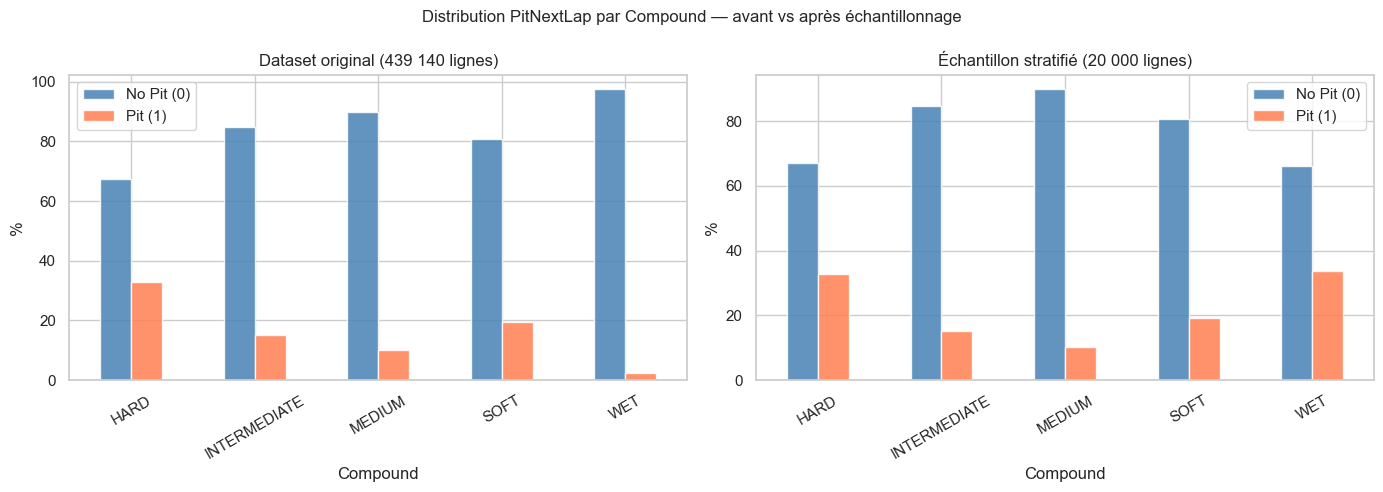

In [5]:
# Visualisation : Compound × PitNextLap avant / après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(
    axes,
    [df_full, df],
    ["Dataset original (439 140 lignes)", "Échantillon stratifié (20 000 lignes)"],
):
    ct = data.groupby(["Compound", "PitNextLap"]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=ax, color=["steelblue", "coral"], alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Compound")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(["No Pit (0)", "Pit (1)"])

plt.suptitle("Distribution PitNextLap par Compound — avant vs après échantillonnage", fontsize=12)
plt.tight_layout()
plt.show()

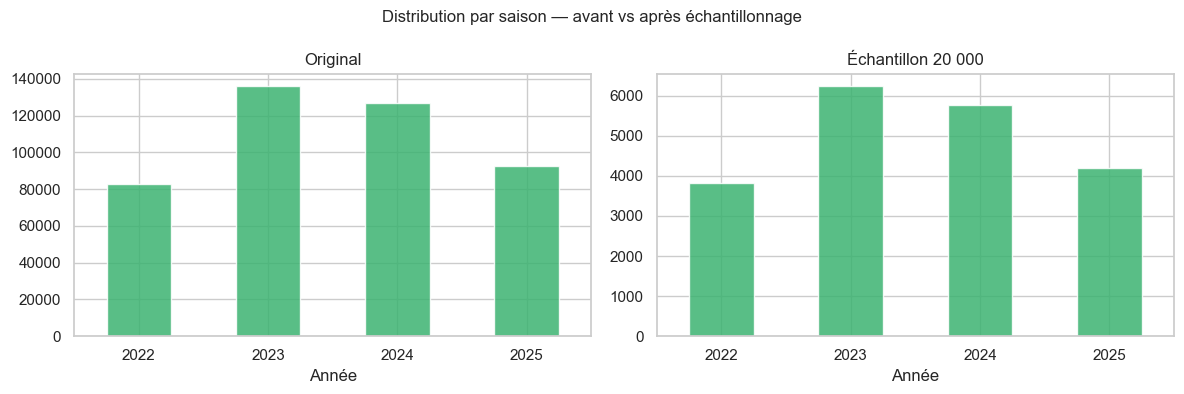

In [6]:
# Distribution par année dans l'échantillon
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(
    axes,
    [df_full, df],
    ["Original", "Échantillon 20 000"],
):
    data["Year"].value_counts().sort_index().plot(
        kind="bar", ax=ax, color="mediumseagreen", alpha=0.85
    )
    ax.set_title(title)
    ax.set_xlabel("Année")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Distribution par saison — avant vs après échantillonnage", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Exploration des données (EDA) — sur l'échantillon

In [7]:
explore_data(df)

Shape : 20,000 lignes × 16 colonnes

── Types & valeurs manquantes ──
                          dtype  null  null_%  nunique
id                        int64     0   0.000    20000
Driver                   object     0   0.000      636
Compound                 object     0   0.000        5
Race                     object     0   0.000       26
Year                      int64     0   0.000        4
PitStop                   int64     0   0.000        2
LapNumber                 int64     0   0.000       77
Stint                     int64     0   0.000        8
TyreLife                float64     0   0.000       69
Position                  int64     0   0.000       20
LapTime (s)             float64     0   0.000    11295
LapTime_Delta           float64     0   0.000    11026
Cumulative_Degradation  float64     0   0.000    16262
RaceProgress            float64     0   0.000     1072
Position_Change         float64     0   0.000       36
PitNextLap              float64     0   0.000     

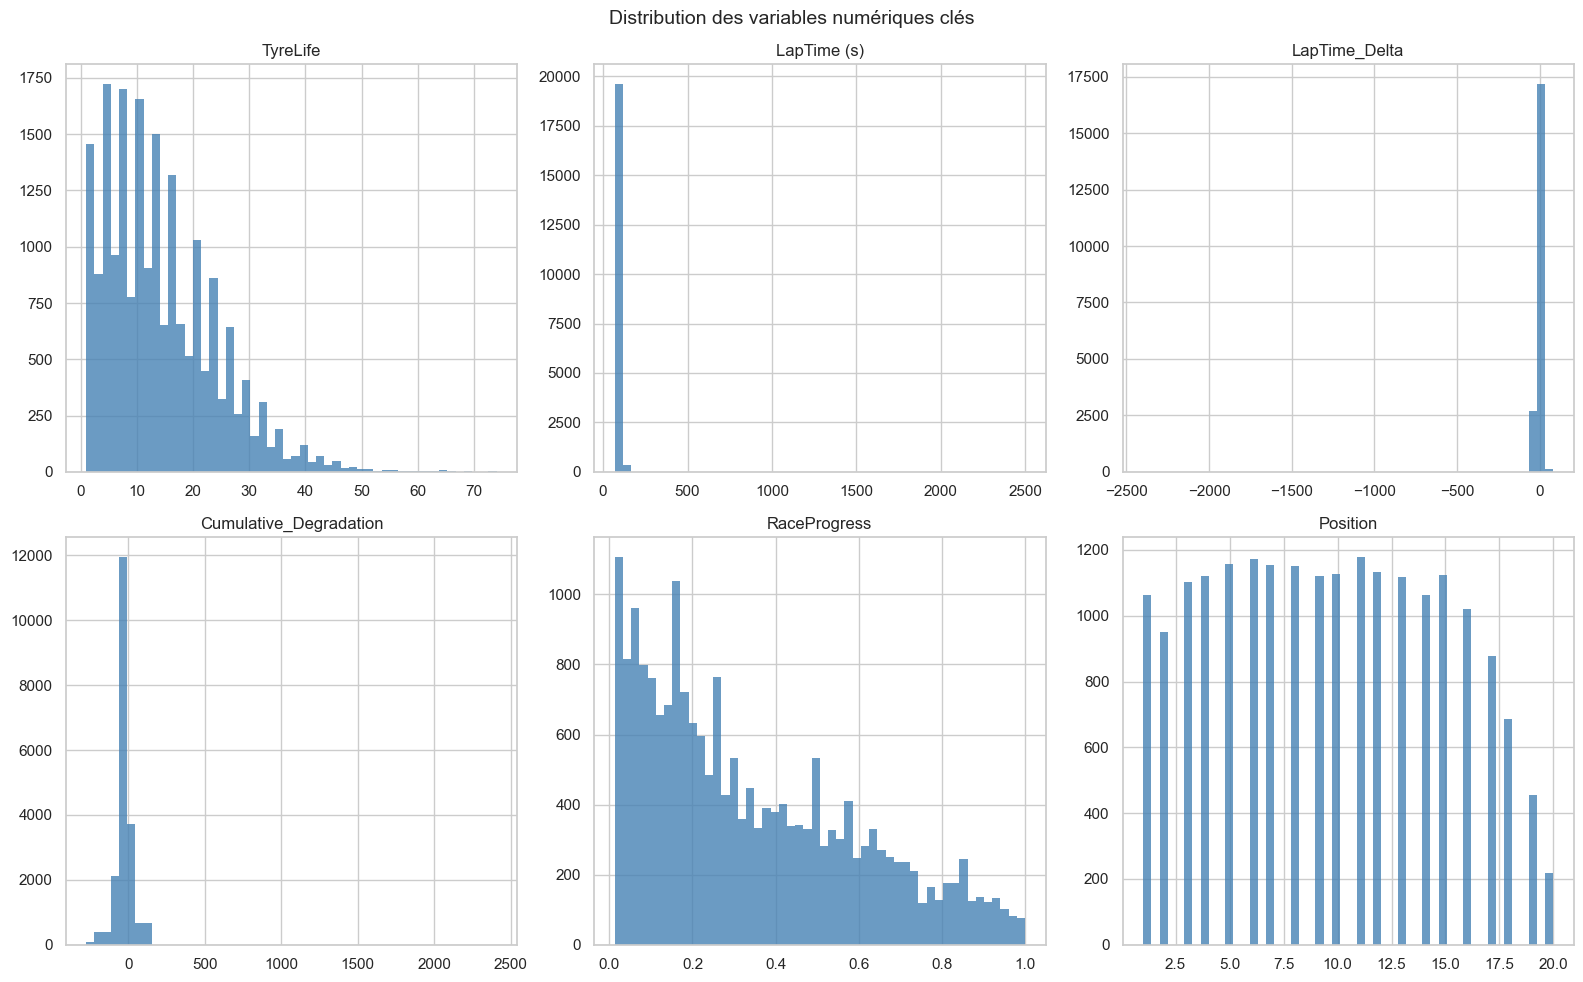

In [8]:
plot_distributions(df)

/Users/fandatongnia/Documents/Majeuredata/Majeure-data-eng/src/data.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pit_rate, x="Compound", y="PitNextLap", ax=ax, palette="viridis")


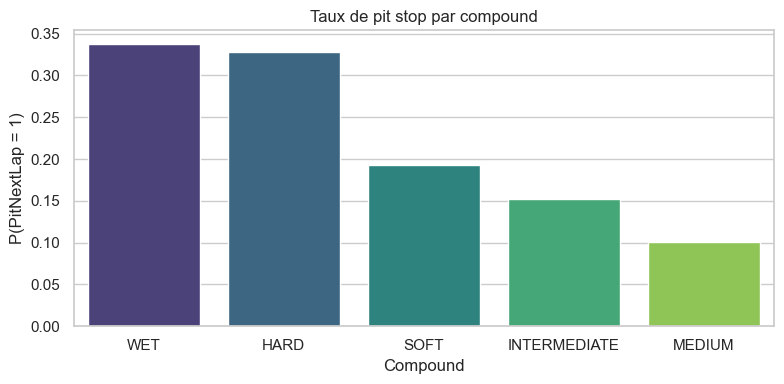

In [9]:
plot_target_by_compound(df)

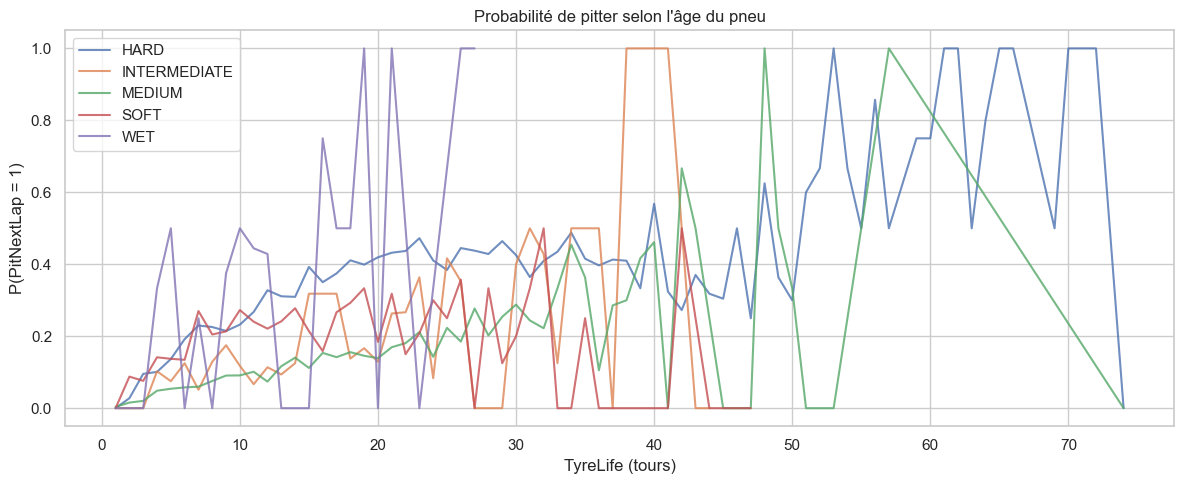

In [10]:
plot_target_by_tyre_life(df)

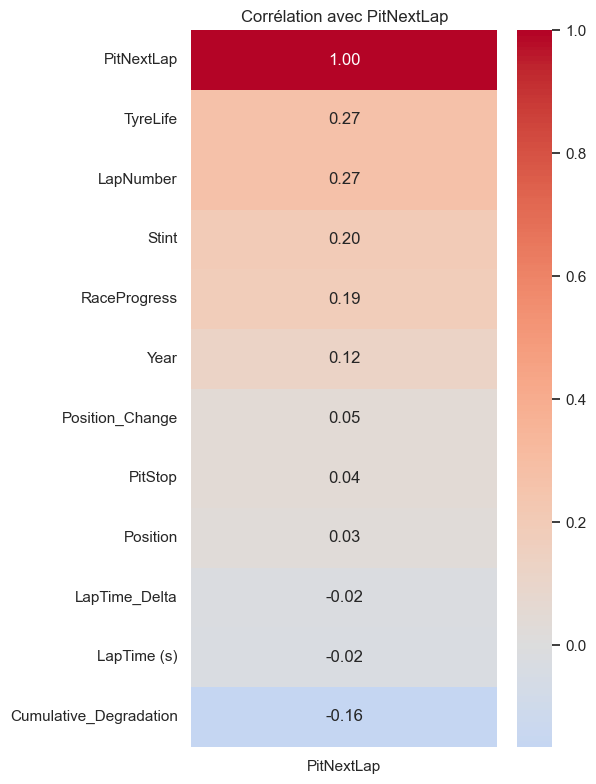

In [11]:
plot_correlation(df)

## 4. Feature Engineering

| Groupe | Features créées | Pourquoi |
|---|---|---|
| **Compound** | `Compound_ordinal`, `Is_Soft`, `Is_Hard`... | Encoder l'info catégorielle du pneu |
| **Pneu** | `TyreLife_sq`, `TyreLife_Pct`, `DegradationRate`... | La dégradation s'accélère non-linéairement |
| **Course** | `RemainingRace`, `In_Pit_Window`, phases... | La fenêtre de pit est entre 30-75% de la course |
| **Stint** | `Is_First_Stint`, `Is_Last_Stint`... | Le comportement diffère selon le relais |
| **Position** | `Is_Leading`, `Is_In_Points`, `Is_Losing_Pos`... | La position influence la stratégie |
| **Interactions** | `Tyre_Stress`, `Degradation_x_Progress`... | Combiner les signaux pour plus de puissance |
| **Encodage** | `Driver_target_enc`, `Race_target_enc`... | Encoder les variables à haute cardinalité |

In [12]:
df_feat = build_features(df)

print(f"Features originales : {df.shape[1]}")
print(f"Nouvelles features  : {len(NEW_FEATURES)}")
print(f"Total après FE      : {df_feat.shape[1]}")

Features originales : 16
Nouvelles features  : 35
Total après FE      : 51


### 4.1 Encodage compound

In [13]:
compound_cols = ["Compound", "Compound_ordinal", "Is_Soft", "Is_Hard", "Is_Medium", "Is_Wet_Compound"]
df_feat[compound_cols].drop_duplicates(subset=["Compound"]).sort_values("Compound_ordinal")

,Compound,Compound_ordinal,Is_Soft,Is_Hard,Is_Medium,Is_Wet_Compound
235,WET,0,0,0,0,1
74,INTERMEDIATE,1,0,0,0,1
0,HARD,2,0,1,0,0
2,MEDIUM,3,0,0,1,0
18,SOFT,4,1,0,0,0


### 4.2 Features de dégradation pneu

In [14]:
tyre_cols = ["TyreLife", "TyreLife_sq", "TyreLife_log", "TyreLife_Pct",
             "TyreLife_Remaining", "DegradationRate", "DegradationPerLap"]
df_feat[tyre_cols].describe().round(3)

,TyreLife,TyreLife_sq,TyreLife_log,TyreLife_Pct,TyreLife_Remaining,DegradationRate,DegradationPerLap
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,14.243,299.471,2.487,0.326,29.815,-2.869,-0.719
std,9.830,407.619,0.743,0.214,11.709,18.929,17.494
min,1.000,1.000,0.693,0.018,-34.000,-171.472,-2399.154
25%,6.000,36.000,1.946,0.150,22.000,-4.450,-0.736
50%,12.000,144.000,2.565,0.300,31.000,-1.729,-0.021
75%,20.000,400.000,3.045,0.455,37.000,-0.475,0.010
max,74.000,5476.000,4.317,1.000,54.000,2406.800,64.372


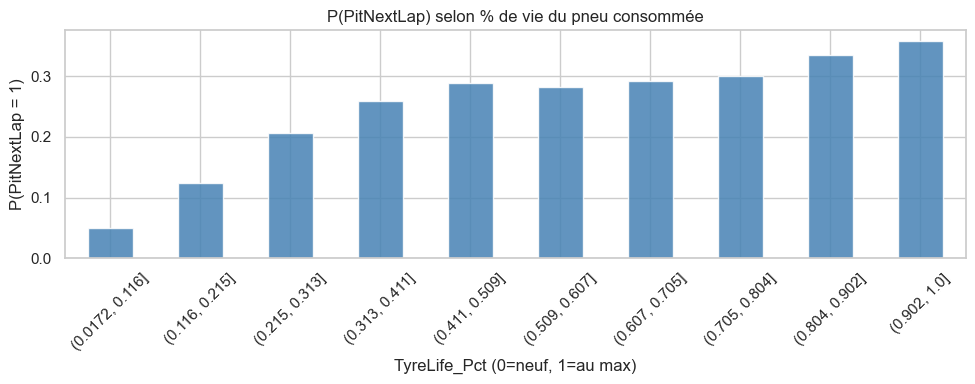

In [15]:
bins = pd.cut(df_feat["TyreLife_Pct"], bins=10)
pit_by_pct = df_feat.groupby(bins, observed=True)["PitNextLap"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
pit_by_pct.plot(kind="bar", ax=ax, color="steelblue", alpha=0.85)
ax.set_title("P(PitNextLap) selon % de vie du pneu consommée")
ax.set_xlabel("TyreLife_Pct (0=neuf, 1=au max)")
ax.set_ylabel("P(PitNextLap = 1)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Features de progression de course

In [16]:
progress_cols = ["RaceProgress", "RemainingRace", "In_Pit_Window",
                 "Is_Early_Race", "Is_Mid_Race", "Is_Late_Race"]
df_feat[progress_cols].describe().round(3)

,RaceProgress,RemainingRace,In_Pit_Window,Is_Early_Race,Is_Mid_Race,Is_Late_Race
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,0.338,0.662,0.379,0.396,0.491,0.114
std,0.254,0.254,0.485,0.489,0.500,0.317
min,0.013,0.000,0.000,0.000,0.000,0.000
25%,0.128,0.486,0.000,0.000,0.000,0.000
50%,0.269,0.731,0.000,0.000,0.000,0.000
75%,0.514,0.872,1.000,1.000,1.000,0.000
max,1.000,0.987,1.000,1.000,1.000,1.000


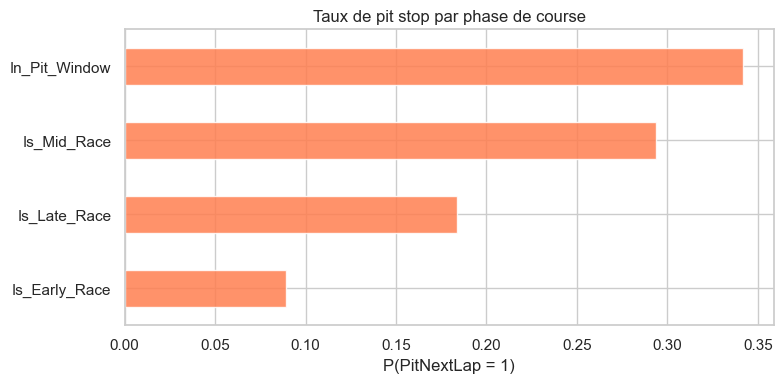

In [17]:
phase_cols = ["Is_Early_Race", "Is_Mid_Race", "Is_Late_Race", "In_Pit_Window"]
phase_pit = {col: df_feat[df_feat[col] == 1]["PitNextLap"].mean() for col in phase_cols}

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(phase_pit).sort_values().plot(kind="barh", ax=ax, color="coral", alpha=0.85)
ax.set_title("Taux de pit stop par phase de course")
ax.set_xlabel("P(PitNextLap = 1)")
plt.tight_layout()
plt.show()

### 4.4 Features de position

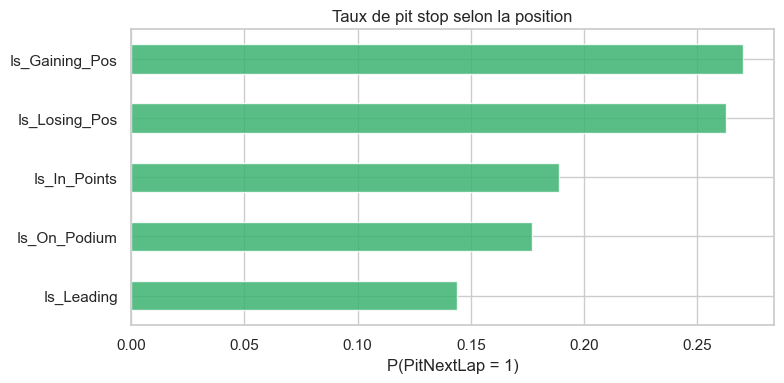

In [18]:
pos_cols = ["Is_Leading", "Is_On_Podium", "Is_In_Points", "Is_Losing_Pos", "Is_Gaining_Pos"]
pos_pit = {col: df_feat[df_feat[col] == 1]["PitNextLap"].mean() for col in pos_cols}

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(pos_pit).sort_values().plot(kind="barh", ax=ax, color="mediumseagreen", alpha=0.85)
ax.set_title("Taux de pit stop selon la position")
ax.set_xlabel("P(PitNextLap = 1)")
plt.tight_layout()
plt.show()

### 4.5 Features d'interaction

In [19]:
interact_cols = ["Compound_x_TyreLife", "TyreLife_x_Position",
                 "Degradation_x_Progress", "Tyre_Stress"]
df_feat[interact_cols].describe().round(3)

,Compound_x_TyreLife,TyreLife_x_Position,Degradation_x_Progress,Tyre_Stress
count,20000.000,20000.000,20000.000,20000.000
mean,35.496,130.902,-10.545,0.980
std,24.228,120.641,20.832,1.101
min,0.000,1.000,-190.367,0.000
25%,16.000,40.000,-15.219,0.264
50%,32.000,96.000,-5.569,0.628
75%,50.000,182.000,-0.850,1.358
max,222.000,969.000,102.461,60.170


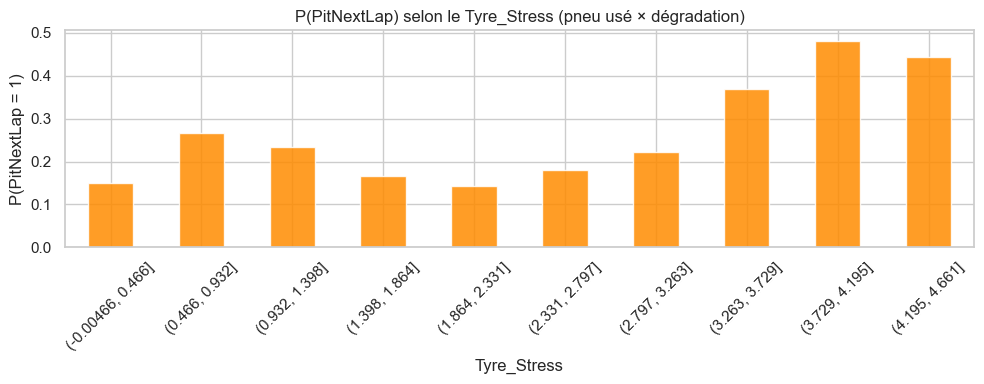

In [20]:
bins_stress = pd.cut(
    df_feat["Tyre_Stress"].clip(upper=df_feat["Tyre_Stress"].quantile(0.99)),
    bins=10,
)
stress_pit = df_feat.groupby(bins_stress, observed=True)["PitNextLap"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
stress_pit.plot(kind="bar", ax=ax, color="darkorange", alpha=0.85)
ax.set_title("P(PitNextLap) selon le Tyre_Stress (pneu usé × dégradation)")
ax.set_xlabel("Tyre_Stress")
ax.set_ylabel("P(PitNextLap = 1)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 4.6 Encodage Driver & Race (Target Encoding)

In [21]:
print("Top 10 pilotes — taux de pit le plus élevé :")
driver_pit = df_feat.groupby("Driver")["Driver_target_enc"].first().sort_values(ascending=False)
print(driver_pit.head(10).round(3))

print("\nTop 10 circuits — taux de pit le plus élevé :")
race_pit = df_feat.groupby("Race")["Race_target_enc"].first().sort_values(ascending=False)
print(race_pit.head(10).round(3))

Top 10 pilotes — taux de pit le plus élevé :
Driver
D381   1.000
D455   1.000
D272   0.667
VET    0.625
MSC    0.600
D371   0.500
BOR    0.500
HAD    0.500
D405   0.500
LAT    0.476
Name: Driver_target_enc, dtype: float64

Top 10 circuits — taux de pit le plus élevé :
Race
Chinese Grand Prix          0.364
Monaco Grand Prix           0.353
Spanish Grand Prix          0.329
Bahrain Grand Prix          0.289
Emilia Romagna Grand Prix   0.286
Belgian Grand Prix          0.264
São Paulo Grand Prix        0.256
French Grand Prix           0.254
Azerbaijan Grand Prix       0.244
Saudi Arabian Grand Prix    0.236
Name: Race_target_enc, dtype: float64


## 5. Aperçu final — Corrélation de toutes les nouvelles features

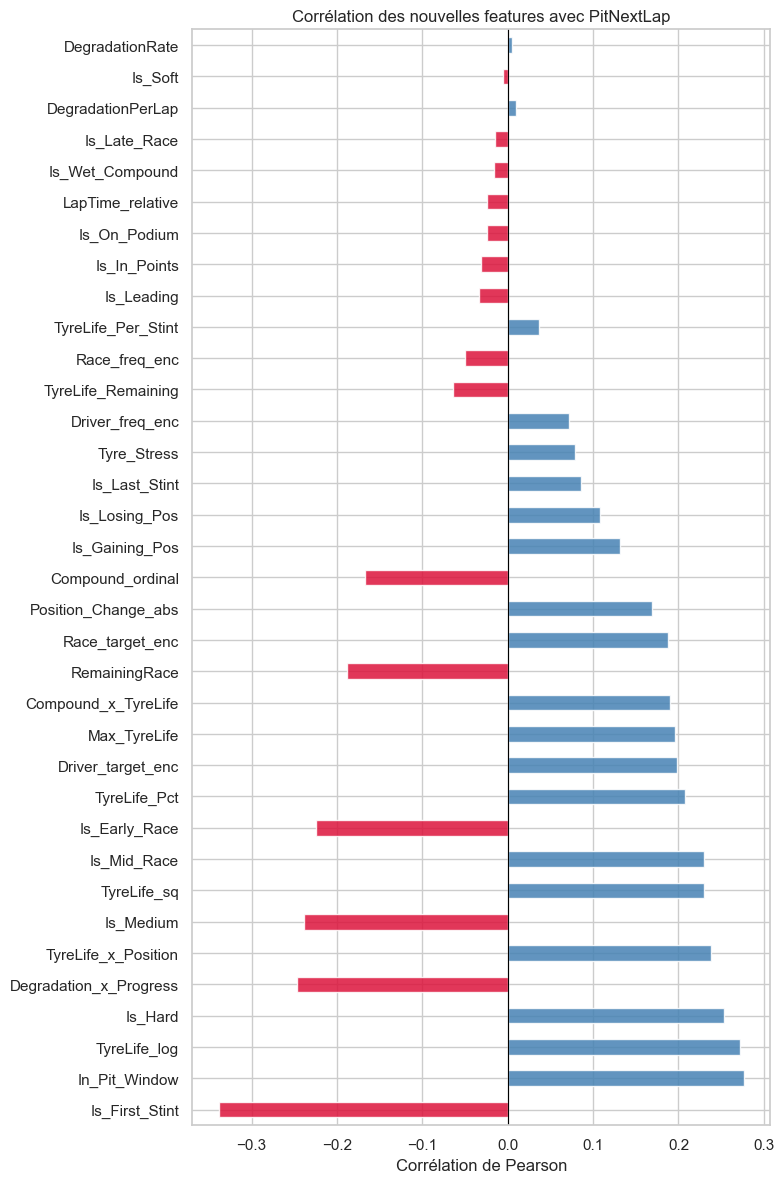

Is_First_Stint           -0.339
In_Pit_Window             0.277
TyreLife_log              0.272
Is_Hard                   0.254
Degradation_x_Progress   -0.247
TyreLife_x_Position       0.238
Is_Medium                -0.238
TyreLife_sq               0.230
Is_Mid_Race               0.229
Is_Early_Race            -0.225
TyreLife_Pct              0.208
Driver_target_enc         0.198
Max_TyreLife              0.196
Compound_x_TyreLife       0.190
RemainingRace            -0.188
Race_target_enc           0.188
Position_Change_abs       0.169
Compound_ordinal         -0.167
Is_Gaining_Pos            0.132
Is_Losing_Pos             0.108
Is_Last_Stint             0.086
Tyre_Stress               0.079
Driver_freq_enc           0.071
TyreLife_Remaining       -0.064
Race_freq_enc            -0.050
TyreLife_Per_Stint        0.036
Is_Leading               -0.033
Is_In_Points             -0.032
Is_On_Podium             -0.025
LapTime_relative         -0.024
Is_Wet_Compound          -0.016
Is_Late_

In [22]:
corr_new = (
    df_feat[NEW_FEATURES + ["PitNextLap"]]
    .corr()["PitNextLap"]
    .drop("PitNextLap")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 12))
colors = ["crimson" if v < 0 else "steelblue" for v in corr_new.values]
corr_new.plot(kind="barh", ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Corrélation des nouvelles features avec PitNextLap")
ax.set_xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

print(corr_new.round(3))

In [23]:
print(f"Dataset final : {df_feat.shape[0]:,} lignes × {df_feat.shape[1]} colonnes")
df_feat[NEW_FEATURES].head(5)

Dataset final : 20,000 lignes × 51 colonnes


,Compound_ordinal,Is_Soft,Is_Hard,Is_Medium,Is_Wet_Compound,TyreLife_sq,TyreLife_log,DegradationRate,DegradationPerLap,Max_TyreLife,TyreLife_Remaining,TyreLife_Pct,RemainingRace,In_Pit_Window,Is_Early_Race,Is_Mid_Race,Is_Late_Race,Is_First_Stint,Is_Last_Stint,TyreLife_Per_Stint,Is_Leading,Is_On_Podium,Is_In_Points,Is_Losing_Pos,Is_Gaining_Pos,Position_Change_abs,Compound_x_TyreLife,TyreLife_x_Position,Degradation_x_Progress,Tyre_Stress,Driver_target_enc,Race_target_enc,Driver_freq_enc,Race_freq_enc,LapTime_relative
0,2,0,1,0,0,1600.000,3.714,-1.246,-0.002,55,15.000,0.727,0.023,0,0,0,1,0,0,20.000,0,0,1,0,1,1.000,80.000,360.000,-48.695,0.906,0.281,0.153,0.003,0.042,0.964
1,2,0,1,0,0,484.000,3.135,-1.222,1.351,55,33.000,0.400,0.711,0,0,1,0,0,0,11.000,0,0,0,0,1,5.000,44.000,242.000,-7.781,0.489,0.500,0.244,0.001,0.026,1.030
2,3,0,0,1,0,144.000,2.565,8.986,-0.406,40,28.000,0.300,0.842,0,1,0,0,1,0,12.000,0,0,1,0,1,2.000,36.000,120.000,17.027,2.696,0.200,0.196,0.003,0.029,0.959
3,3,0,0,1,0,25.000,1.792,-4.996,-2.816,40,35.000,0.125,0.944,0,1,0,0,1,0,5.000,0,0,0,0,1,6.000,15.000,60.000,-1.407,0.624,0.292,0.167,0.003,0.032,1.218
4,2,0,1,0,0,169.000,2.639,-4.004,-0.376,55,42.000,0.236,0.486,1,0,1,0,0,1,4.333,0,0,0,1,0,3.000,26.000,182.000,-26.751,0.946,0.238,0.254,0.003,0.006,0.988


## 6. Sauvegarde

In [ ]:
df_feat.to_csv("data/train_features.csv", index=False)
print("Sauvegardé → data/train_features.csv")
print(f"Shape finale : {df_feat.shape}")

## 7. Modélisation — Random Forest

**Pourquoi Random Forest ?**
- Pas besoin de scaler les features
- Gère le déséquilibre 80/20 avec `class_weight='balanced'`
- Donne la **feature importance** → valide directement notre feature engineering
- Bonne performance sans tuning complexe

**Split stratifié :** le ratio 80/20 (no pit / pit) est préservé dans train ET test.

In [ ]:
from src.model import (
    split_data,
    train_random_forest,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
)

### 7.1 Split Train / Test

In [ ]:
X_train, X_test, y_train, y_test = split_data(df_feat, test_size=0.2, random_state=42)

print(f"\nDistribution target dans le train :")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribution target dans le test :")
print(y_test.value_counts(normalize=True).round(3))

### 7.2 Entraînement

In [ ]:
model = train_random_forest(
    X_train,
    y_train,
    n_estimators=200,
    max_depth=15,
    random_state=42,
)

### 7.3 Évaluation

Pour un problème déséquilibré (80/20), on regarde en priorité :
- **Recall (classe 1)** : parmi tous les pits réels, combien on a détectés ?
- **Precision (classe 1)** : parmi nos prédictions pit, combien sont vrais ?
- **F1-score** : équilibre precision / recall
- **AUC-ROC** : performance globale (1.0 = parfait, 0.5 = aléatoire)

In [ ]:
results = evaluate_model(model, X_test, y_test)

### 7.4 Matrice de confusion

In [ ]:
plot_confusion_matrix(y_test, results["y_pred"])

### 7.5 Courbe ROC

In [ ]:
plot_roc_curve(y_test, results["y_proba"], results["auc"])

### 7.6 Feature Importance

Quelles features construites dans la section 4 sont les plus utiles pour le modèle ?

In [ ]:
plot_feature_importance(model, X_train, top_n=20)

## 8. MLflow — Suivi d'expériences

### Étape 1 — Démarrer le serveur MLflow (dans un terminal)

```bash
mlflow server --host 127.0.0.1 --port 5000 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```

Puis ouvrir : http://localhost:5000

### Étape 2 — Lancer les 3 modèles (dans un terminal)

```bash
# Un modèle à la fois (pour comparer chaque run)
python -m src.train --model rf
python -m src.train --model xgb
python -m src.train --model lgbm

# Ou les 3 d'un coup
python -m src.train --model all
```

Chaque commande :
- Lance un **GridSearchCV** pour trouver les meilleurs hyperparamètres
- Crée un **run MLflow** avec params + métriques + modèle + matrice de confusion
- Affiche le résumé dans le terminal

### Étape 3 — Comparer les runs dans l'UI

Dans l'UI MLflow → expérience `F1-PitStop-Prediction` → sélectionner les 3 runs → **Compare**

| Ce qu'on compare | Métrique clé |
|---|---|
| Quel modèle détecte le mieux les pits ? | **Recall (classe 1)** |
| Quel modèle a le moins de fausses alarmes ? | **Precision (classe 1)** |
| Quel modèle est le plus équilibré ? | **F1-score** |
| Quel modèle discrimine le mieux globalement ? | **AUC-ROC** |

In [ ]:
# Récupère et affiche les résultats de tous les runs de l'expérience
import mlflow
from src.config import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.tracking.MlflowClient()

experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"],
)

summary = []
for r in runs:
    summary.append({
        "run_name": r.data.tags.get("mlflow.runName", r.info.run_id[:8]),
        "f1":       r.data.metrics.get("f1", None),
        "roc_auc":  r.data.metrics.get("roc_auc", None),
        "accuracy": r.data.metrics.get("accuracy", None),
        "recall":   r.data.metrics.get("recall", None),
        "run_id":   r.info.run_id,
    })

import pandas as pd
df_runs = pd.DataFrame(summary)
print("Résultats MLflow — expérience :", MLFLOW_EXPERIMENT)
df_runs

In [ ]:
# Visualisation comparaison AUC et F1 des 3 modèles
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["roc_auc", "f1"]):
    df_runs.sort_values(metric, ascending=False).plot(
        kind="bar", x="run_name", y=metric,
        ax=ax, color=["mediumseagreen", "steelblue", "coral"], alpha=0.85, legend=False
    )
    ax.set_title(metric.upper().replace("_", "-"))
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

plt.suptitle("Comparaison des 3 modèles — MLflow runs", fontsize=13)
plt.tight_layout()
plt.show()